[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FranQuant/llm-regime-allocator/blob/main/notebooks/nb05_counterfactual.ipynb)

In [1]:
# Colab setup: fetch the repo (data, results and the replayable LLM cache), work from its notebooks/ folder.
# Runs only on Colab; locally this cell does nothing. No API keys or paid calls are needed.
import os, subprocess, sys
if 'google.colab' in sys.modules and not os.path.exists('../src/lra'):
    repo = '/content/llm-regime-allocator'
    if not os.path.exists(repo):
        subprocess.run(['git', 'clone', '-q', '--depth', '1',
                        'https://github.com/FranQuant/llm-regime-allocator.git', repo], check=True)
    os.chdir(f'{repo}/notebooks')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'pydantic>=2', 'scikit-learn'], check=True)

# nb05 — Reading or remembering? A counterfactual test

**Question.** nb04 left a question no backtest can answer: when an LLM calls a regime from a historical snapshot, does it read the figures or recall the month? GPT, which names the exact month of almost any blinded snapshot, makes it pressing. nb05 edits the snapshot and re-asks. Everything is read from `python scripts/score_phase9.py`; no API calls.

## Setup

**Edits.** On the blinded snapshot, flip the sign of every inflation z-score (headline and core CPI: level, 3-month and 12-month change; 6 numbers), or of every growth z-score (industrial production, activity index, payrolls, unemployment; 12 numbers). Rates, curve, credit, VIX, dollar and all market lines stay as they were. A model that reads the data should move; one answering from memory has no reason to.

**Design** (pre-registered in `configs/phase9.toml` before any paid call). 30 months per edit: 15 where the block is clearly up and 15 clearly down (|signal| ≥ 0.75), spread over 2007–2026 by a fixed rule.

**Primary test.** The answer moves by $\mathrm{moved}_t=\mathrm{TV}(p^{\text{edit}}_t,\,p_t)$ with $\mathrm{TV}(p,q)=\tfrac12\sum_k|p_k-q_k|$. The noise baseline is the same distance when the *unedited* snapshot is asked a second time, $\mathrm{noise}_t=\mathrm{TV}(p^{\text{re-ask}}_t,\,p_t)$. A model *reads the data* if the mean of $\mathrm{moved}_t-\mathrm{noise}_t$ has a bootstrap CI above zero for both edits.

**Secondary (descriptive).** *Signed shift* is the change in the probability of the regimes the edit should favour (inflation: Reflation + Stagflation; growth: Goldilocks + Reflation), signed so that positive means the answer moved the way the edited figures imply. Walk-forward ML on the same blinded inputs is a deterministic yardstick (noise = 0).

In [2]:
import sys
sys.path.insert(0, '../src')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from lra.evaluation import R
P9, L = Path('../results/phase9'), Path('../results/llm')
C = {'claude_sonnet': '#2a78d6', 'gpt_sol': '#eb6834', 'gemini_flash': '#1baf7a', 'glm': '#eda100',
     'ml_logit_blinded': '#8a8984', 'ml_gbt_blinded': '#b5b4ae'}
NAME = {'claude_sonnet': 'Sonnet 5.5', 'gpt_sol': 'GPT-6.1-sol', 'gemini_flash': 'Gemini 3.8 Flash',
        'glm': 'GLM-5.3', 'ml_logit_blinded': 'ML logit', 'ml_gbt_blinded': 'ML GBT'}
INK, MUTED = '#0b0b0b', '#52514e'
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'axes.edgecolor': MUTED, 'text.color': INK})

def fmt(df, pct=(), d0=(), d1=(), d2=()):
    """Display only: Sharpe 2 decimals, Brier 3, percentages 0 (stored results are untouched)."""
    f = {**{c: '{:.0%}' for c in pct}, **{c: '{:.0f}' for c in d0}, **{c: '{:.1f}' for c in d1}, **{c: '{:.2f}' for c in d2}}
    return df.style.format(f, precision=3, na_rep='–')
sh = pd.read_csv(P9 / 'shifts.csv')

## 1. One month, by hand

December 2021: inflation was surging, and GPT names this month from the blinded snapshot. What does it say when the inflation figures are flipped to read *cooling*?

In [3]:
d = '2021-12-31'
rows = {}
for m in ('gpt_sol', 'claude_sonnet'):
    rows[(NAME[m], 'true snapshot')] = pd.read_csv(L / m / 'blinded_run0.csv', index_col='date').loc[d, R]
    rows[(NAME[m], 'inflation flipped')] = pd.read_csv(L / m / 'blinded_cf_infl_run0.csv', index_col='date').loc[d, R]
pd.DataFrame(rows).T.astype(float).round(2)

Goldilocks  Reflation  Stagflation  Risk_Off
GPT-6.1-sol true snapshot            0.10       0.53         0.31      0.06
            inflation flipped        0.57       0.10         0.06      0.27
Sonnet 5.5  true snapshot            0.10       0.50         0.25      0.15
            inflation flipped        0.48       0.28         0.07      0.17

**Reading.** Both models move probability from the inflation-up regimes (Reflation + Stagflation) to the inflation-down ones, GPT from 0.84 to 0.16 and Sonnet from 0.75 to 0.35, while the rest of the snapshot still looks like late 2021.

## 2. The pre-registered test: edits against re-asking

In [4]:
t = sh.copy(); t['forecaster'] = t.forecaster.map(NAME)
fmt(t.set_index(['forecaster', 'edit'])[['moved_tv', 'noise_tv', 'moved_minus_noise', 'ci_lo', 'ci_hi']])

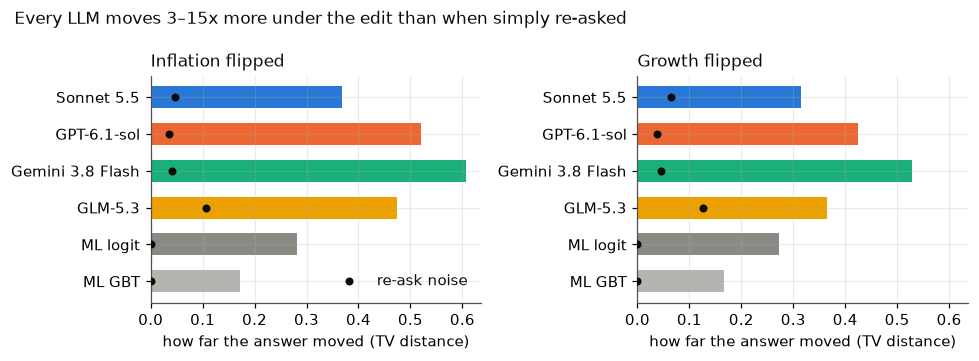

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.3), sharex=True)
order = list(NAME)
for ax, e, title in zip(axes, ('infl', 'growth'), ('Inflation flipped', 'Growth flipped')):
    s = sh[sh.edit == e].set_index('forecaster').loc[order]
    y = np.arange(len(s))[::-1]
    ax.barh(y, s.moved_tv, color=[C[k] for k in s.index], height=0.6)
    ax.scatter(s.noise_tv, y, color=INK, zorder=3, s=18, label='re-ask noise')
    ax.set_yticks(y, [NAME[k] for k in s.index]); ax.set_title(title, loc='left', fontsize=11)
    ax.set_xlabel('how far the answer moved (TV distance)')
axes[0].legend(frameon=False, loc='lower right')
fig.suptitle('Every LLM moves 3–15x more under the edit than when simply re-asked', x=0.02, ha='left', fontsize=11)
plt.tight_layout(); plt.show()

In [6]:
v = pd.read_csv(P9 / 'verdict.csv'); v['forecaster'] = v.forecaster.map(NAME); v

,forecaster,edits_scored,reads_data
0,Sonnet 5.5,2,True
1,GPT-6.1-sol,2,True
2,Gemini 3.8 Flash,2,True
3,GLM-5.3,2,True


**Reading.** **Key finding:** all four LLMs pass. Under either edit their answer moves 0.31–0.61 in TV distance, against 0.04–0.13 when the same snapshot is asked again: 3–15 times more. **Control:** the deterministic ML models, which cannot remember anything, move less (0.17–0.28).

## 3. Direction (secondary)

Signed shift as defined in Setup.

In [7]:
t.set_index(['forecaster', 'edit'])[['signed_shift', 'signed_ci_lo', 'signed_ci_hi', 'follow_rate',
    'ignored_rate', 'against_rate']].pipe(fmt, pct=['follow_rate', 'ignored_rate', 'against_rate'])

**Reading.** The LLMs move the expected way in 87–100% of months, for growth as well as inflation. The ML models follow the inflation edit weakly and the growth edit not at all; the pre-registration anticipated this, since over three months a strong growth reading can legitimately imply slowing growth. The LLMs' answers fit the textbook reading of the regime definitions, which history only partly supports.

## 4. Does knowing the month make a model ignore the data?

In [8]:
s2 = pd.read_csv(P9 / 'secondary.csv'); fmt(s2)

,comparison,edit,n,mean,ci_lo,ci_hi
0,gpt_sol minus claude_sonnet (moved - noise),infl,30,0.163,0.112,0.215
1,gpt_sol minus claude_sonnet (moved - noise),growth,30,0.136,0.095,0.180
2,claude_sonnet: datable minus not datable (moved - noise),infl,18/12,-0.056,–,–
3,claude_sonnet: datable minus not datable (moved - noise),growth,11/19,-0.044,–,–
4,gpt_sol: datable minus not datable (moved - noise),infl,29/1,-0.151,–,–
5,gpt_sol: datable minus not datable (moved - noise),growth,30/0,–,–,–
6,gemini_flash: datable minus not datable (moved - noise),infl,22/8,0.054,–,–
7,gemini_flash: datable minus not datable (moved - noise),growth,14/16,-0.136,–,–


**Reading.** **Key finding:** no. GPT, which dates almost every one of these snapshots, follows the edits more than Sonnet does (+0.16 and +0.14 TV, CIs above zero). Within Sonnet and Gemini, months they can date show no consistent difference from months they cannot (small samples, descriptive).

## What we can and cannot claim

- **The answers are not invariant to the data.** Change the figures and every model changes its call, in the direction the figures imply and far beyond its run-to-run noise, GPT included although it knows the month. A pure lookup of the month would not do that.
- **This is a sensitivity result, not proof of skill.** A model can read the figures *and* lean on what it remembers about what came next, and an edited snapshot may be read as a different episode. The edits do not show that the model stops recognising the original month, or that memory adds nothing.
- **Following the figures is not the same as being right:** the direction results say how the models read the data, not that the reading predicts the next quarter.
- **Limits.** 30 months per edit, one edit size (a full sign flip), one run per edited snapshot. The edited snapshots are internally inconsistent by design (cooling inflation with unchanged yields), which may push answers around; the ML yardstick shows how much a pure data reader moves on the same edits.

## Next

The one test model memory cannot touch is prospective. From the October 2026 month-end, one blinded call per model per month is committed to an append-only log (`results/live/log.csv`, rules in `configs/phase10.toml`). No prospective month has been scored yet; the first checkpoint comes after 12 scored months.